In [1]:
import os
import re
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm

import albumentations as A
import segmentation_models_pytorch as smp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [2]:
CFG = {
    "data_root": r"C:\Users\ASHAH\Desktop\DL_Project\breast_ultrasound\Dataset_BUSI_with_GT",
    "img_size": 320,
    "batch_size": 8,
    "epochs": 25,
    "lr": 1e-3,
    "num_workers": 0,
    "encoder_name": "timm-efficientnet-b3",   # fallback: "efficientnet-b3"
    "threshold": 0.5,
}

In [3]:
DATASET_ROOT = Path(CFG["data_root"])

def base_key(filename: str) -> str:
    name = filename.replace(".png", "")
    name = re.sub(r"_mask(_\d+)?$", "", name)
    return name

rows = []

for cls_name in ["benign", "malignant", "normal"]:
    cls_dir = DATASET_ROOT / cls_name
    pngs = sorted(cls_dir.glob("*.png"))

    images = {}
    masks = {}

    for p in pngs:
        fname = p.name
        key = base_key(fname)

        if "_mask" in fname:
            masks.setdefault(key, []).append(str(p))
        else:
            images[key] = str(p)

    for key, img_path in images.items():
        rows.append({
            "image_path": img_path,
            "mask_paths": masks.get(key, []),
            "label": cls_name
        })

df = pd.DataFrame(rows)
print(df.head())
print(df["label"].value_counts())
print("Total:", len(df))

                                          image_path  \
0  C:\Users\ASHAH\Desktop\DL_Project\breast_ultra...   
1  C:\Users\ASHAH\Desktop\DL_Project\breast_ultra...   
2  C:\Users\ASHAH\Desktop\DL_Project\breast_ultra...   
3  C:\Users\ASHAH\Desktop\DL_Project\breast_ultra...   
4  C:\Users\ASHAH\Desktop\DL_Project\breast_ultra...   

                                          mask_paths   label  
0  [C:\Users\ASHAH\Desktop\DL_Project\breast_ultr...  benign  
1  [C:\Users\ASHAH\Desktop\DL_Project\breast_ultr...  benign  
2  [C:\Users\ASHAH\Desktop\DL_Project\breast_ultr...  benign  
3  [C:\Users\ASHAH\Desktop\DL_Project\breast_ultr...  benign  
4  [C:\Users\ASHAH\Desktop\DL_Project\breast_ultr...  benign  
label
benign       437
malignant    210
normal       133
Name: count, dtype: int64
Total: 780


In [4]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print(train_df["label"].value_counts(), "\n")

print("Valid:", len(valid_df))
print(valid_df["label"].value_counts(), "\n")

print("Test:", len(test_df))
print(test_df["label"].value_counts())

Train: 546
label
benign       306
malignant    147
normal        93
Name: count, dtype: int64 

Valid: 117
label
benign       65
malignant    32
normal       20
Name: count, dtype: int64 

Test: 117
label
benign       66
malignant    31
normal       20
Name: count, dtype: int64


In [5]:
#Augmentations
train_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.10,
        rotate_limit=10,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),
])

valid_tfms = A.Compose([
    A.Resize(CFG["img_size"], CFG["img_size"]),
])

C:\Users\ASHAH\anaconda3\envs\ml_env\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:
#Dataset Class
class BUSISegDataset(Dataset):
    def __init__(self, df, transforms=None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def _load_merged_mask(self, mask_paths, shape_hw):
        h, w = shape_hw
        merged = np.zeros((h, w), dtype=np.uint8)

        for mp in mask_paths:
            m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            if m is None:
                raise FileNotFoundError(mp)
            merged = np.maximum(merged, (m > 0).astype(np.uint8) * 255)

        return (merged > 0).astype(np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise FileNotFoundError(row["image_path"])

        mask_paths = row["mask_paths"]
        if isinstance(mask_paths, list) and len(mask_paths) > 0:
            mask = self._load_merged_mask(mask_paths, image.shape)
        else:
            mask = np.zeros_like(image, dtype=np.float32)

        if self.transforms is not None:
            transformed = self.transforms(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        image = image.astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)  # [1, H, W]
        mask = np.expand_dims(mask.astype(np.float32), axis=0)

        return {
            "image": torch.tensor(image, dtype=torch.float32),
            "mask": torch.tensor(mask, dtype=torch.float32),
        }

In [7]:
#DataLoader
train_ds = BUSISegDataset(train_df, transforms=train_tfms)
valid_ds = BUSISegDataset(valid_df, transforms=valid_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True
)

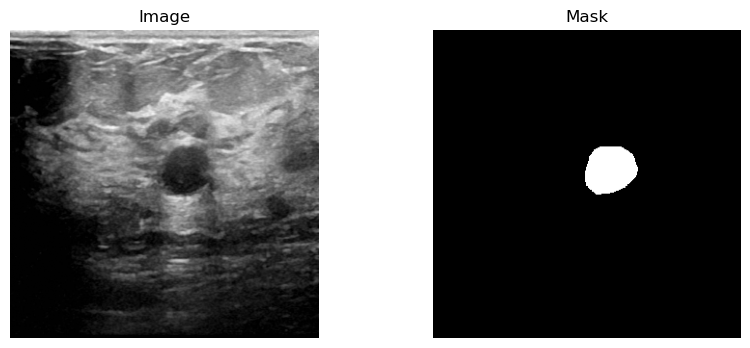

In [8]:
#visual sanity check
sample = train_ds[0]
img = sample["image"][0].numpy()
msk = sample["mask"][0].numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(msk, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

In [9]:
#Initialize model
model = smp.DeepLabV3Plus(
    encoder_name=CFG["encoder_name"],
    encoder_weights='imagenet',     # FROM SCRATCH
    in_channels=1,
    classes=1,
    activation=None
).to(device)

print(type(model))

<class 'segmentation_models_pytorch.decoders.deeplabv3.model.DeepLabV3Plus'>


In [10]:
#Quickshape test
x = torch.randn(2, 1, CFG["img_size"], CFG["img_size"]).to(device)
with torch.no_grad():
    y = model(x)
print(y.shape)   # expected: [2, 1, H, W]

torch.Size([2, 1, 320, 320])


In [11]:
#Loss func
dice_loss = smp.losses.DiceLoss(mode="binary", from_logits=True)
bce_loss = nn.BCEWithLogitsLoss()

def compute_loss(logits, masks):
    return dice_loss(logits, masks) + bce_loss(logits, masks)

In [12]:
#Dice metrics
def dice_score_from_logits(logits, masks, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    inter = (preds * masks).sum(dim=(1,2,3))
    union = preds.sum(dim=(1,2,3)) + masks.sum(dim=(1,2,3))
    dice = (2 * inter + eps) / (union + eps)
    return dice.mean().item()

In [13]:
#Optimizer and amp
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG["lr"])
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

In [14]:
#Train loop
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    running_dice = 0.0

    pbar = tqdm(loader, total=len(loader))
    for batch in pbar:
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = compute_loss(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits.detach(), masks)

        pbar.set_postfix({
            "loss": f"{running_loss/(pbar.n+1):.4f}",
            "dice": f"{running_dice/(pbar.n+1):.4f}"
        })

    return running_loss / len(loader), running_dice / len(loader)

In [15]:
#Valid loop
@torch.no_grad()
def valid_one_epoch(model, loader):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0

    for batch in tqdm(loader, total=len(loader)):
        images = batch["image"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            logits = model(images)
            loss = compute_loss(logits, masks)

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits, masks)

    return running_loss / len(loader), running_dice / len(loader)

In [16]:
#Training the model
best_dice = -1
history = {
    "train_loss": [],
    "train_dice": [],
    "val_loss": [],
    "val_dice": []
}

for epoch in range(CFG["epochs"]):
    train_loss, train_dice = train_one_epoch(model, train_loader)
    val_loss, val_dice = valid_one_epoch(model, valid_loader)

    history["train_loss"].append(train_loss)
    history["train_dice"].append(train_dice)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    print(f"\nEpoch {epoch+1}/{CFG['epochs']}")
    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_deeplabv3plus_busi_scratch.pth")
        print("Saved best_deeplabv3plus_busi_scratch.pth")
        

  0%|          | 0/69 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch 1/25
Train Loss: 0.8306 | Train Dice: 0.4789
Val   Loss: 0.6421 | Val Dice: 0.5740
Saved best_deeplabv3plus_busi_scratch.pth


  0%|          | 0/69 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch 24/25
Train Loss: 0.2489 | Train Dice: 0.8110
Val   Loss: 0.4402 | Val Dice: 0.7606


  0%|          | 0/69 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]


Epoch 25/25
Train Loss: 0.2450 | Train Dice: 0.8294
Val   Loss: 0.3990 | Val Dice: 0.7482


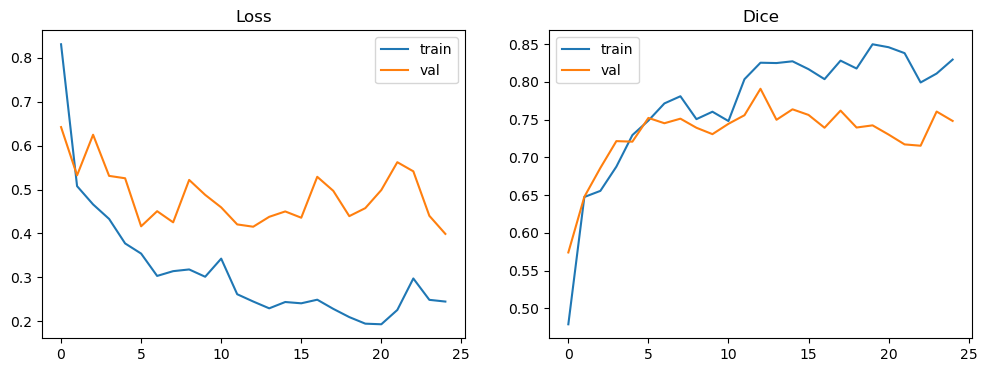

In [17]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history["train_dice"], label="train")
plt.plot(history["val_dice"], label="val")
plt.title("Dice")
plt.legend()

plt.show()

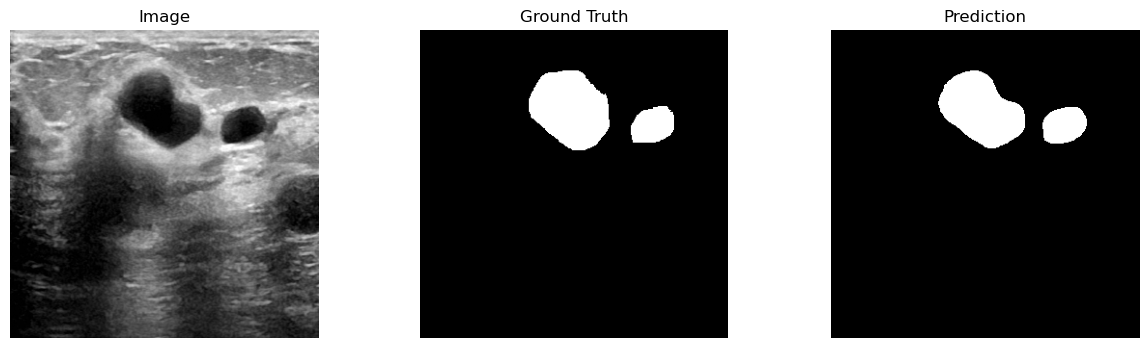

In [18]:
model.load_state_dict(torch.load("best_deeplabv3plus_busi_scratch.pth", map_location=device))
model.eval()

sample = valid_ds[0]
image = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image)
    pred_mask = (torch.sigmoid(logits)[0, 0] > CFG["threshold"]).float().cpu().numpy()

img = sample["image"][0].numpy()
gt_mask = sample["mask"][0].numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

In [19]:
test_ds = BUSISegDataset(test_df, transforms=valid_tfms)

test_loader = DataLoader(
    test_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [20]:
model.load_state_dict(torch.load("best_deeplabv3plus_busi_scratch.pth", map_location=device))
model.eval()

test_loss, test_dice = valid_one_epoch(model, test_loader)
print(f"Test Loss: {test_loss:.4f} | Test Dice: {test_dice:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]

Test Loss: 0.3748 | Test Dice: 0.7871


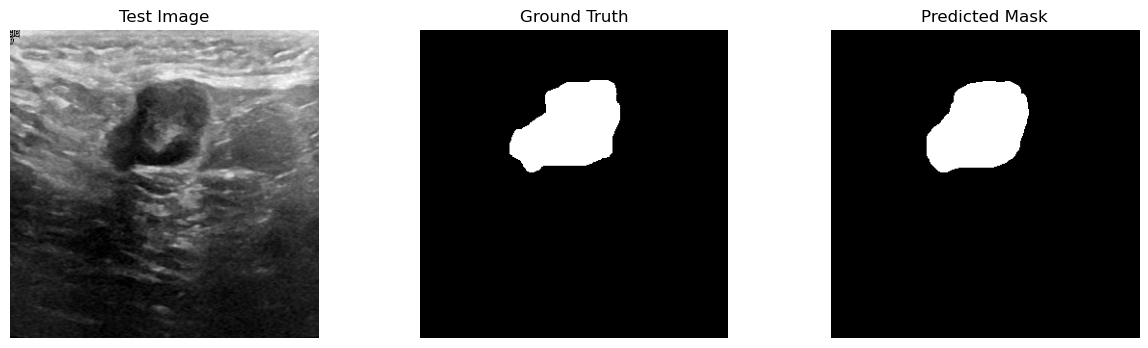

In [21]:
sample = test_ds[0]
image = sample["image"].unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image)
    pred_mask = (torch.sigmoid(logits)[0, 0] > CFG["threshold"]).float().cpu().numpy()

img = sample["image"][0].numpy()
gt_mask = sample["mask"][0].numpy()

import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Test Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gt_mask, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()